# Fig. 2 — Histogram: comparing two distributions

This notebook shows how to plot pre-computed histogram data from a JSON summary file.

Key points illustrated here:
- Loading bin edges and density from a summary file (not raw samples)
- Using `ax.stairs()` for plotting pre-computed histograms
- Adding a vertical line for the ground truth value
- Using `alpha` for overlapping filled histograms
- Using different line styles (solid vs. dashed) to distinguish methods even in grayscale

In [1]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from cb_colors import palettes

# ── Version switch ────────────────────────────────────────────────────────────
VERSION = "paper"   # "paper" | "slides" | "dark"

# ── Load style ────────────────────────────────────────────────────────────────
matplotlib.rc_file("../../../matplotlibrc_ml")

# ── Figure size ───────────────────────────────────────────────────────────────
TEXTWIDTH = 5.5    # NeurIPS full text width in inches

if VERSION == "paper":
    FIGWIDTH  = TEXTWIDTH * 0.48  # ~half a text width → sits beside another panel
    FONT_SIZE = 7.5
    SUFFIX    = ""
    TRANSPARENT = True
elif VERSION == "slides":
    FIGWIDTH  = 4.5
    FONT_SIZE = 13.0
    SUFFIX    = "_slides"
    TRANSPARENT = False
elif VERSION == "dark":
    FIGWIDTH  = 4.5
    FONT_SIZE = 13.0
    SUFFIX    = "_dark"
    TRANSPARENT = True

matplotlib.rcParams.update({"font.size": FONT_SIZE})

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
with open("../data/example_data.json") as f:
    data = json.load(f)

print(data["description"])

Samples from two models for a 1D parameter estimate. Histogram computed from 500 samples each.


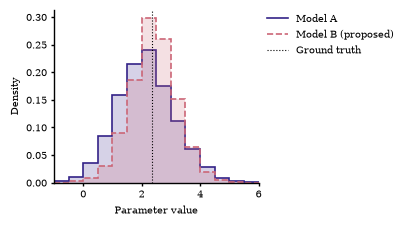

In [3]:
# ── Colors ────────────────────────────────────────────────────────────────────
# paul_tol_muted: soft tones suit filled/overlapping histograms well
c = palettes.paul_tol_muted()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIGWIDTH, FIGWIDTH * 0.85))

for key, color, ls in [
    ("model_a", c["indigo"],  "-"),
    ("model_b", c["rose"],  "--"),
]:
    d = data[key]
    edges   = np.array(d["bin_edges"])
    density = np.array(d["density"])

    # stairs() takes N values and N+1 edges
    ax.stairs(density, edges, color=color, linestyle=ls, label=d["label"], linewidth=1.2)
    ax.stairs(density, edges, color=color, fill=True, alpha=0.2, linewidth=0)

# Ground truth marker
gt = data["ground_truth"]
ax.axvline(gt, color="black", linewidth=0.8, linestyle=":", label="Ground truth")

ax.set_xlabel(data["x_label"])
ax.set_ylabel(data["y_label"])
ax.set_xlim(data["model_a"]["bin_edges"][0], data["model_a"]["bin_edges"][-1])

# Legend outside to the right — bbox_inches='tight' (set in matplotlibrc) will include it
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

if VERSION == "dark":
    BG = "#1c1c2e"
    FG = "white"
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.tick_params(colors=FG)
    ax.xaxis.label.set_color(FG)
    ax.yaxis.label.set_color(FG)
    for spine in ax.spines.values():
        spine.set_edgecolor(FG)

plt.show()


In [4]:
# ── Save ──────────────────────────────────────────────────────────────────────
out_path = f"../pdf/fig_02{SUFFIX}.pdf"
fig.savefig(out_path, transparent=TRANSPARENT)
print(f"Saved: {out_path}")

Saved: ../pdf/fig_02.pdf
